In [95]:
# import necessary libraries:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [96]:
# run code from data_input folder:
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

In [97]:
data = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
data = data.set_index('Date')

#df_benchmark = pd.read_csv("benchmark_returns.csv", parse_dates=['Date'])
#df_benchmark = df_benchmark.set_index('Date')

#data = pd.concat([df_benchmark,df_factors], axis=1, join='inner')
data = data.dropna()

In [98]:
print(data)

            Momentum     Value   Quality
Date                                    
2007-03-05  0.018613  0.015753 -0.010966
2007-03-12 -0.012887 -0.020257  0.048512
2007-03-19  0.060268  0.052751  0.014917
2007-03-26  0.022670  0.007935  0.007713
2007-04-02  0.010079  0.009888  0.018702
...              ...       ...       ...
2024-01-01 -0.020676 -0.025835 -0.022511
2024-01-08  0.002769 -0.000758  0.008803
2024-01-15 -0.014716 -0.035979  0.007137
2024-01-22  0.029946  0.027634 -0.013507
2024-01-29 -0.006574 -0.005330  0.014779

[879 rows x 3 columns]


In [99]:
# List of factor columns and the benchmark
cols = ['Momentum', 'Value', 'Quality']

# Compute cumulative returns for each column
cum_returns = (1 + data[cols]).cumprod() - 1

# Optional: format as percentages
#cum_returns = cum_returns * 100

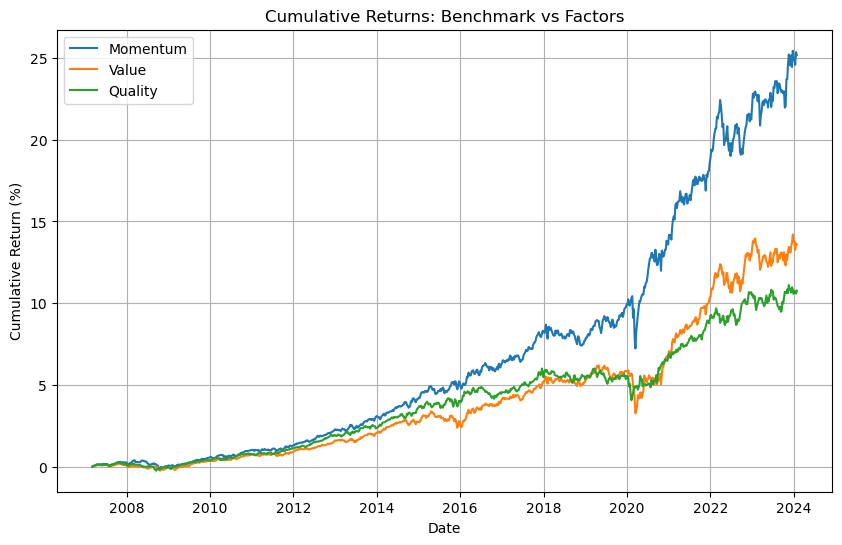

In [100]:
plt.figure(figsize=(10, 6))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)

plt.title("Cumulative Returns: Benchmark vs Factors")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [108]:
import pandas as pd
import numpy as np

# =========================================================
# 0. HELPER FUNCTIONS
# =========================================================

def compute_strength_scores(row):
    """Bradley–Terry strength scoring."""
    p_MV = row["p_M_gt_V"]
    p_MQ = row["p_M_gt_Q"]
    p_VQ = row["p_V_gt_Q"]

    Momentum  =  p_MV + p_MQ
    Value     = -(1 - p_MV) + p_VQ
    Quality   = -(1 - p_MQ) -(1 - p_VQ)

    return pd.Series([Momentum, Value, Quality],
                     index=["Momentum_score", "Value_score", "Quality_score"])


def softmax_weights(row):
    """Softmax over scores."""
    x = row[["Momentum_score","Value_score","Quality_score"]].values
    e = np.exp(x - np.max(x))
    w = e / e.sum()
    return pd.Series(w, index=["Momentum_w","Value_w","Quality_w"])


def build_portfolio(weights_raw, name, factor_ret):
    """
    Build a portfolio given any weight matrix (weekly or monthly-scaled).
    - Lags weights by 1 week
    - Merges w/ returns
    - Computes turnover, Sharpe, cumulative return
    """
    # 1. Lag weights to avoid look-ahead
    weights_lagged = weights_raw.shift(1)

    # 2. Merge with factor returns
    df_port = factor_ret.join(weights_lagged, how="inner").dropna()

    # 3. Compute weekly portfolio return
    df_port[f"{name}_return"] = (
          df_port["Momentum"] * df_port["Momentum_w"]
        + df_port["Value"]    * df_port["Value_w"]
        + df_port["Quality"]  * df_port["Quality_w"]
    )

    # 4. Cumulative return
    df_port[f"{name}_cumret"] = (1 + df_port[f"{name}_return"]).cumprod() - 1

    # 5. Sharpe (annualized)
    mu = df_port[f"{name}_return"].mean()
    sigma = df_port[f"{name}_return"].std()
    sharpe = (mu / sigma) * np.sqrt(52)

    # 6. Turnover
    df_port[f"{name}_turnover"] = (
        df_port[["Momentum_w","Value_w","Quality_w"]]
        .diff().abs().sum(axis=1) / 2
    )

    avg_wk = df_port[f"{name}_turnover"].mean()
    annual_turnover = avg_wk * 52

    return {
        "name": name,
        "Sharpe": sharpe,
        "Cumulative Return": df_port[f"{name}_cumret"].iloc[-1],
        "Avg Weekly Turnover": avg_wk,
        "Annual Turnover": annual_turnover
    }, df_port


# =========================================================
# 1. LOAD LOGISTIC MODEL PROBABILITIES
# =========================================================

mv = pd.read_csv("log_momentum_value_probs.csv", parse_dates=["Date"]).set_index("Date")
mq = pd.read_csv("log_momentum_quality_probs.csv", parse_dates=["Date"]).set_index("Date")
vq = pd.read_csv("log_value_quality_probs.csv", parse_dates=["Date"]).set_index("Date")

mv = mv.rename(columns={"probability":"p_M_gt_V"})
mq = mq.rename(columns={"probability":"p_M_gt_Q"})
vq = vq.rename(columns={"probability":"p_V_gt_Q"})

df_probs = mv[["p_M_gt_V"]].join(
    [mq[["p_M_gt_Q"]], vq[["p_V_gt_Q"]]],
    how="inner"
)


# =========================================================
# 2. COMPUTE SCORES + WEEKLY SOFTMAX
# =========================================================

scores = df_probs.apply(compute_strength_scores, axis=1)
weights_weekly = scores.apply(softmax_weights, axis=1)


# =========================================================
# 3. MONTHLY REBALANCING WEIGHTS
# =========================================================

weights_monthly = weights_weekly.resample("BME").last()
weights_monthly_ffill = weights_monthly.reindex(weights_weekly.index).ffill().bfill()


# =========================================================
# 4. FACTOR RETURNS
# =========================================================

factor_ret = pd.read_csv("factor_returns.csv", parse_dates=["Date"]).set_index("Date")


# =========================================================
# 5. BUILD BOTH PORTFOLIOS
# =========================================================

monthly_metrics, df_monthly = build_portfolio(weights_monthly_ffill, "monthly", factor_ret)
weekly_metrics,  df_weekly  = build_portfolio(weights_weekly,         "weekly",  factor_ret)


# =========================================================
# 6. COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Rebalance": "Monthly",
        **monthly_metrics
    },
    {
        "Model": "Logistic Regression",
        "Rebalance": "Weekly",
        **weekly_metrics
    }
])[["Model","Rebalance","Sharpe","Cumulative Return","Avg Weekly Turnover","Annual Turnover"]]

print("\n====================== REBALANCE COMPARISON ======================\n")
print(comparison.to_string(index=False))
print("\n=================================================================\n")



====================== REBALANCE COMPARISON ======================

              Model Rebalance   Sharpe  Cumulative Return  Avg Weekly Turnover  Annual Turnover
Logistic Regression   Monthly 1.229067           0.627033             0.000560         0.029136
Logistic Regression    Weekly 1.199120           0.609508             0.013301         0.691657


